# Grafana Data - Analysis of MockPT Data - Phase 2 - MQTT & OPC-UA

In [201]:
import pandas as pd
import matplotlib.pyplot as plt

# Experiment Phase Folder
experiment_phase = "phase-2"


## Network Analysis Functions

In [202]:
# Network Functions

# Function to read Grafana Network CSV File
def read_grafana_network_file(filename):

    # Load Edge and Cloud Network CSV
    target_df = pd.read_csv(filename)

    # Convert timestamp to ms
    target_df['Time'] = pd.to_datetime(target_df['Time'])
    target_df['timestamp_ms'] = (target_df['Time'] - target_df['Time'].min()).dt.total_seconds() * 1000

    # Add sample number
    target_df['sample'] = range(len(target_df))

    # Compute Experiment Time in seconds
    target_df['experiment_time_s'] = target_df['timestamp_ms'] / 1000

    # Convert Network columns to MBit/sec
    for col in target_df.columns:
        target_df[col] = target_df[col].apply(to_mbit_per_sec)

    # Fill NaN values with 0
    target_df = target_df.fillna(0)

    # Return Network Dataframe
    return target_df

# Define a function to convert to MBit/sec from various units
def to_mbit_per_sec(value):
    # Converts string like '1.03 MiB/s', '867 KiB/s', '904 B/s', '10.8 kB/s', '141 MB/s', '141 mB/s' to MBit/sec
    if isinstance(value, str):
        v = value.strip()
        v_lower = v.lower()
        try:
            if 'mib/s' in v_lower:
                return float(v_lower.replace(' mib/s', '')) * 8.388608
            elif 'mb/s' in v_lower:
                return float(v_lower.replace(' mb/s', '')) * 8
            elif 'kib/s' in v_lower:
                return float(v_lower.replace(' kib/s', '')) * 0.008192
            elif 'kb/s' in v_lower:
                return float(v_lower.replace(' kb/s', '')) * 0.008
            elif 'b/s' in v_lower:
                return float(v_lower.replace(' b/s', '')) * 8 / 1_000_000
            else:
                return 0.0
        except Exception:
            return 0.0
    try:
        return float(value)
    except Exception:
        return 0.0

# Define a function to convert to Kbit / sec from various units
def to_kbit_per_sec(value):
    # Use the above function and convert MBit to KBit
    mbit = to_mbit_per_sec(value)
    return mbit * 1000

## Memory Analysis Functions

In [203]:
# Function to read Grafana Memory CSV File
def read_grafana_memory_file(filename):

    # Load Edge and Cloud Network CSV
    target_df = pd.read_csv(filename)

    # Convert timestamp to ms
    target_df['Time'] = pd.to_datetime(target_df['Time'])
    target_df['timestamp_ms'] = (target_df['Time'] - target_df['Time'].min()).dt.total_seconds() * 1000

    # Add sample number
    target_df['sample'] = range(len(target_df))

    # Compute Experiment Time in seconds
    target_df['experiment_time_s'] = target_df['timestamp_ms'] / 1000

    # Convert Network columns to MBit/sec
    for col in target_df.columns:
        target_df[col] = target_df[col].apply(memory_to_mbit)

    # Fill NaN values with 0
    target_df = target_df.fillna(0)

    # Return Network Dataframe
    return target_df

# Convert memory usage to MBit
def memory_to_mbit(value):
    # Converts string like '1.03 MiB', '867 KiB', '904 B', '10.8 kB', '141 MB', '141 mB' to MBit , 1.32 GiB to MBit
    if isinstance(value, str):
        v = value.strip()
        v_lower = v.lower()
        try:
            if 'mib' in v_lower:
                return float(v_lower.replace(' mib', '')) * 8.388608
            elif 'mb' in v_lower:
                return float(v_lower.replace(' mb', '')) * 8
            elif 'kib' in v_lower:
                return float(v_lower.replace(' kib', '')) * 0.008192
            elif 'kb' in v_lower:
                return float(v_lower.replace(' kb', '')) * 0.008
            elif 'gib' in v_lower:
                return float(v_lower.replace(' gib', '')) * 8589.934592
            elif 'gb' in v_lower:
                return float(v_lower.replace(' gb', '')) * 8000
            elif 'b' in v_lower:
                return float(v_lower.replace(' b', '')) * 8 / 1_000_000
            else:
                return 0.0
        except Exception as e:
            print("Error converting memory value:", e)
            return 0.0
    try:
        return float(value)
    except Exception:
        return 0.0

def memory_to_megabytes(value):
    # Use the above function and convert MBit to MB
    mbit = memory_to_mbit(value)
    return mbit / 8

## CPU Analysis Function

In [204]:
# Read CPU CSV File
def read_grafana_cpu_file(filename):

    # Load Edge and Cloud CPU CSV
    target_df = pd.read_csv(filename)

    # Convert timestamp to ms
    target_df['Time'] = pd.to_datetime(target_df['Time'])
    target_df['timestamp_ms'] = (target_df['Time'] - target_df['Time'].min()).dt.total_seconds() * 1000

    # Add sample number
    target_df['sample'] = range(len(target_df))

    # Compute Experiment Time in seconds
    target_df['experiment_time_s'] = target_df['timestamp_ms'] / 1000

    # Convert % columns to float
    for col in target_df.columns:
        if target_df[col].dtype == object and target_df[col].str.endswith('%').any():
            target_df[col] = target_df[col].str.rstrip('%').astype(float)

    # Fill NaN values with 0
    target_df = target_df.fillna(0)

    # Return CPU Dataframe
    return target_df


## Filtering & Renaming Functions

In [205]:
# Filter by container name and sample range
def filter_by_container_name_list(target_df, container_name_list):
    # Filter columns
    target_df = target_df[['timestamp_ms', 'experiment_time_s', 'sample'] + container_name_list]

    # Focus on samples between 100 and 400
    #df_ditto = df_ditto[(df_ditto['sample'] >= 100) & (df_ditto['sample'] <= 400)]

    return target_df


## Load & Graph CPU Data

Loading CPU data from: data/phase-2/cpu.csv


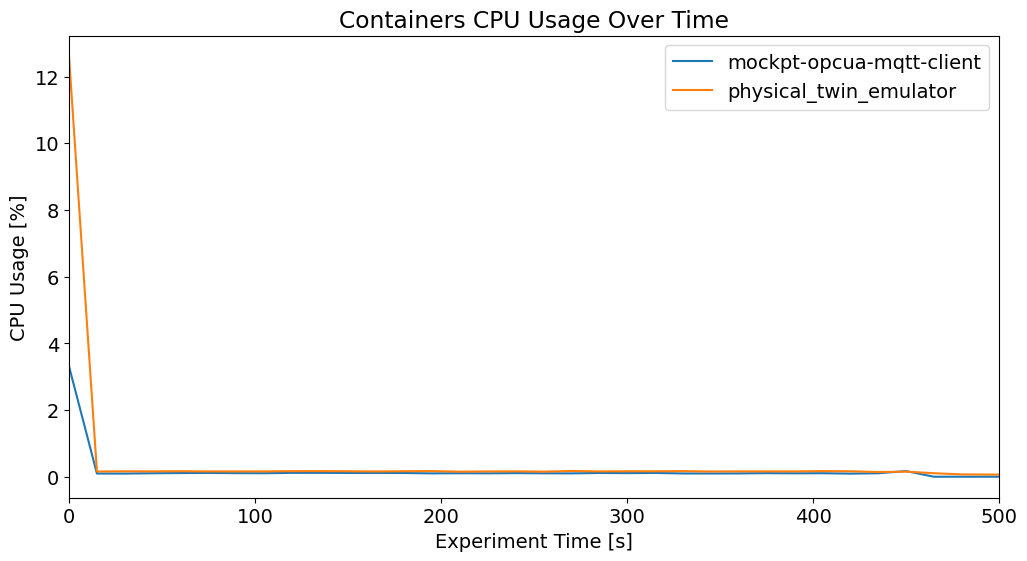

In [206]:
target_cpu_file_path = f'data/{experiment_phase}/cpu.csv'

print("Loading CPU data from:", target_cpu_file_path)

# Load Edge and Cloud CPU CSV
cpu_df = read_grafana_cpu_file(target_cpu_file_path)

# Target Container List
target_container_list = [
    'mockpt-opcua-mqtt-client',
    'physical_twin_emulator'
]

# Filter by target container list
cpu_df = filter_by_container_name_list(cpu_df, target_container_list)

# Plot CPU evolution
plt.figure(figsize=(12, 6))
for container in target_container_list:
    plt.plot(cpu_df['experiment_time_s'], cpu_df[container], label=container)
plt.xlabel('Experiment Time [s]')
plt.ylabel('CPU Usage [%]')
plt.title('Containers CPU Usage Over Time')

# Set Y axis limit to 0-100%
#plt.ylim(0, 0.05)

# Set X axis limit to 0-300 seconds
plt.xlim(0, 500)

plt.legend()
plt.show()


## Load & Graph Network In Data

Loading Network In data from: data/phase-2/net_in.csv


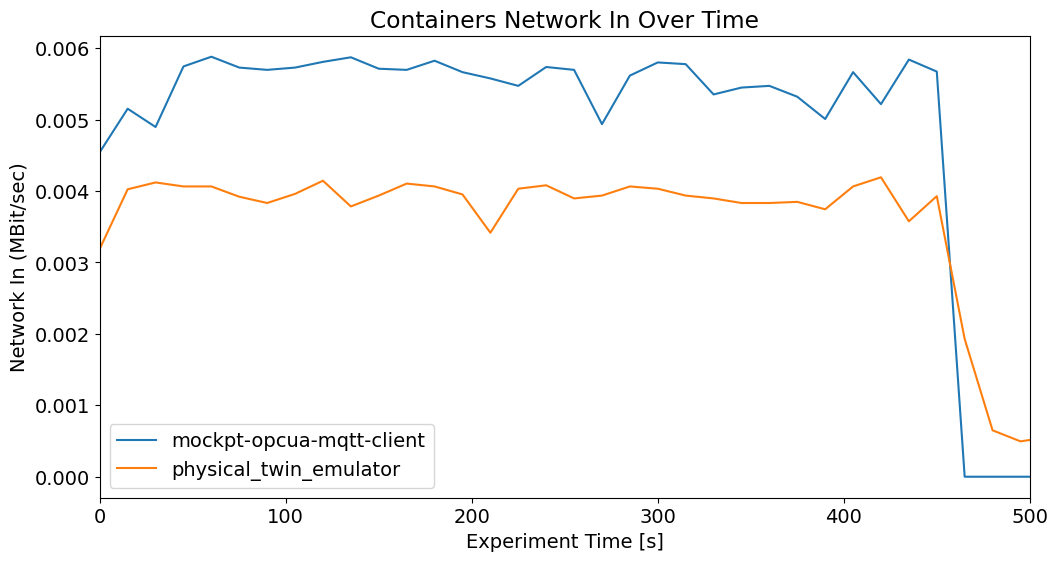

In [207]:
# Read Network CSV File
target_network_in_file_path = f'data/{experiment_phase}/net_in.csv'
print("Loading Network In data from:", target_network_in_file_path)

# Read Network Data
net_in_df = read_grafana_network_file(target_network_in_file_path)

# Filter by target container list
net_in_df = filter_by_container_name_list(net_in_df, target_container_list)

# Plot Network In evolution
plt.figure(figsize=(12, 6))
for container in target_container_list:
    plt.plot(net_in_df['experiment_time_s'], net_in_df[container], label=container)
plt.xlabel('Experiment Time [s]')
plt.ylabel('Network In (MBit/sec)')
plt.title('Containers Network In Over Time')
# Set X axis limit to 0-300 seconds
plt.xlim(0, 500)
plt.legend()
plt.show()

## Load & Graph Network Out Data

Loading Network Out data from: data/phase-2/net_out.csv


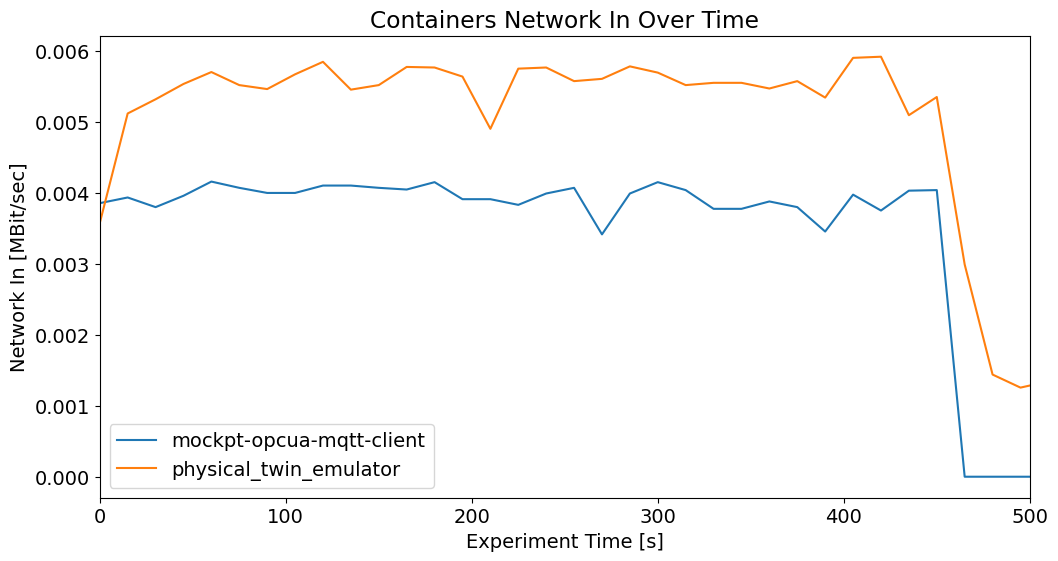

In [208]:
# Read Network CSV File
target_network_out_file_path = f'data/{experiment_phase}/net_out.csv'
print("Loading Network Out data from:", target_network_out_file_path)

# Read Network Data
net_out_df = read_grafana_network_file(target_network_out_file_path)

# Filter by target container list
net_out_df = filter_by_container_name_list(net_out_df, target_container_list)

# Plot Network In evolution
plt.figure(figsize=(12, 6))
for container in target_container_list:
    plt.plot(net_out_df['experiment_time_s'], net_out_df[container], label=container)
plt.xlabel('Experiment Time [s]')
plt.ylabel('Network In [MBit/sec]')
plt.title('Containers Network In Over Time')
# Set X axis limit to 0-300 seconds
plt.xlim(0, 500)
plt.legend()
plt.show()

## Load & Graph Memory Data

Loading Memory data from: data/phase-2/memory.csv


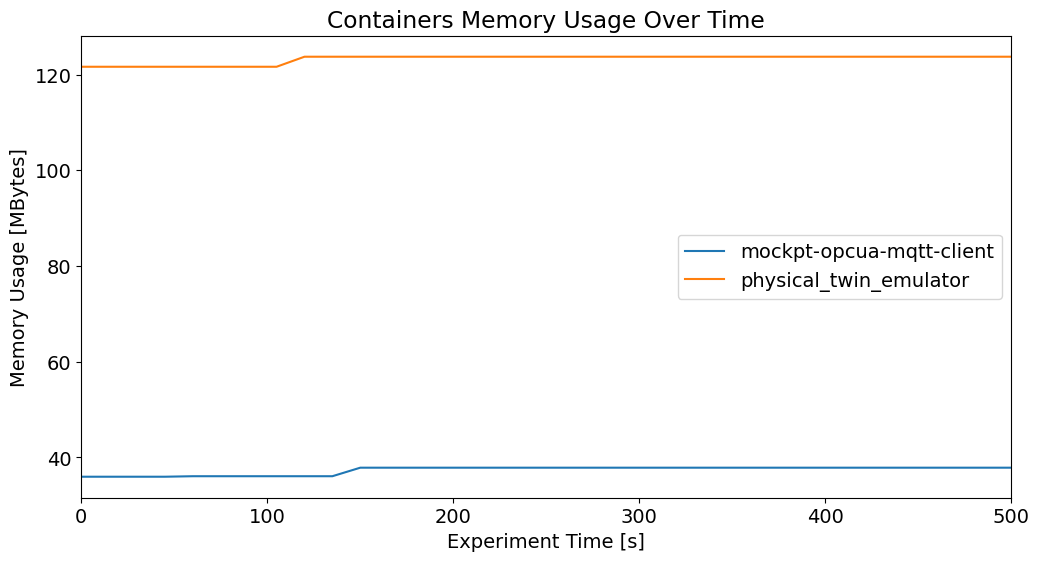

In [209]:
# Read Memory CSV File
target_memory_file_path = f'data/{experiment_phase}/memory.csv'
print("Loading Memory data from:", target_memory_file_path)

# Read Memory Data
memory_df = read_grafana_memory_file(target_memory_file_path)

# Filter by target container list
memory_df = filter_by_container_name_list(memory_df, target_container_list)

# Convert memory from MBit to MBytes
for container in target_container_list:
    memory_df[container] = memory_df[container].apply(lambda x: x / 8)

# Plot Memory evolution
plt.figure(figsize=(12, 6))
for container in target_container_list:
    plt.plot(memory_df['experiment_time_s'], memory_df[container], label=container)
plt.xlabel('Experiment Time [s]')
plt.ylabel('Memory Usage [MBytes]')
plt.title('Containers Memory Usage Over Time')
# Set X axis limit to 0-300 seconds
plt.xlim(0, 500)
plt.legend()
plt.show()

## Integrated Graph: CPU, Network In/Out, Memory

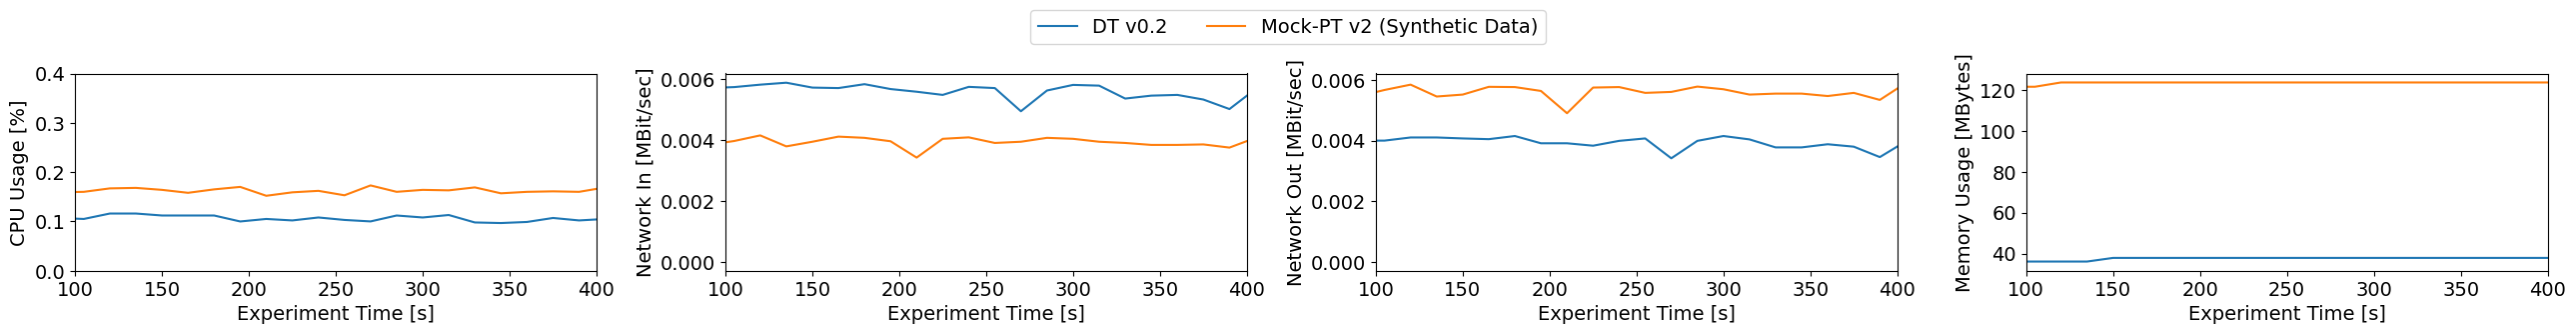

In [210]:
# Increase font size for better readability
plt.rcParams.update({'font.size': 14})

# Create a 1 row, 4 column subplots
fig, axs = plt.subplots(1, 4, figsize=(26, 3))

# Set Data Labels
data_labels = {
    'mockpt-opcua-mqtt-client': 'DT v0.2',
    'physical_twin_emulator': 'Mock-PT v2 (Synthetic Data)'
}

# Plot CPU
for container in target_container_list:
    axs[0].plot(cpu_df['experiment_time_s'], cpu_df[container], label=data_labels[container])
axs[0].set_xlabel('Experiment Time [s]')
axs[0].set_ylabel('CPU Usage [%]')
#axs[0].set_title('Containers CPU Usage Over Time')
axs[0].set_ylim(0, 0.4)
axs[0].set_xlim(100, 400)
#axs[0].legend()

# Plot Network In
for container in target_container_list:
    axs[1].plot(net_in_df['experiment_time_s'], net_in_df[container], label=data_labels[container])
axs[1].set_xlabel('Experiment Time [s]')
axs[1].set_ylabel('Network In [MBit/sec]')
#axs[1].set_title('Containers Network In Over Time')
axs[1].set_xlim(100, 400)
#axs[1].legend()

# Plot Network Out
for container in target_container_list:
    axs[2].plot(net_out_df['experiment_time_s'], net_out_df[container], label=data_labels[container])
axs[2].set_xlabel('Experiment Time [s]')
axs[2].set_ylabel('Network Out [MBit/sec]')
#axs[2].set_title('Containers Network Out Over Time')
axs[2].set_xlim(100, 400)
#axs[2].legend()

# Plot Memory
for container in target_container_list:
    axs[3].plot(memory_df['experiment_time_s'], memory_df[container], label=data_labels[container])
axs[3].set_xlabel('Experiment Time [s]')
axs[3].set_ylabel('Memory Usage [MBytes]')
#axs[3].set_title('Containers Memory Usage Over Time')
axs[3].set_xlim(100, 400)
#axs[3].legend()

# Put Legend outside the plots
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=len(target_container_list))

# Adjust layout
plt.tight_layout()

# Save the figure with high resolution
plt.savefig(f'graph/{experiment_phase}_integrated_graph.pdf', dpi=300, bbox_inches='tight')

plt.show()